In [1]:
import torch
from torch import nn
import torchvision

In [2]:
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [3]:
import sys
import os

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import some helper functions, download it from GitHub if it doesn't work
try:
    import data_setup, engine
    from helper_functions import download_data, plot_loss_curves, set_seeds
except ModuleNotFoundError:
    print("[INFO] Couldn't find python scripts... downloading them from GitHub.")

    !git clone https://github.com/rahulkumarmeena29/ViT-Food101

    # Add the cloned directory to sys.path so Python can find the modules
    sys.path.append('ViT-Food101')

    import data_setup
    import engine
    from helper_functions import download_data, plot_loss_curves, set_seeds

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find python scripts... downloading them from GitHub.
Cloning into 'ViT-Food101'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 75.53 KiB | 618.00 KiB/s, done.
Resolving deltas: 100% (2/2), done.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Getting the Data

In [69]:
# Download pizza, steak, sushi images from GitHub amd if not present in your system
image_path = download_data(source="https://github.com/rahulkumarmeena29/Vision-Transformer-for-Food-classification/raw/refs/heads/main/data/pizza_steak_sushi_dataset.zip",
                           destination="pizza_steak_sushi_dataset")
image_path

[INFO] Did not find data/pizza_steak_sushi_dataset directory, creating it...
[INFO] Downloading pizza_steak_sushi_dataset.zip from https://github.com/rahulkumarmeena29/Vision-Transformer-for-Food-classification/raw/refs/heads/main/data/pizza_steak_sushi_dataset.zip...
[INFO] Unzipping pizza_steak_sushi_dataset.zip data...


PosixPath('data/pizza_steak_sushi_dataset')

In [6]:
#Setup training and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

## 2. Foodvision model deployement experiment outline

### 3 Questions
1. What is my ideal machine learning model deployement scenario?
2. Where is my model going to go?
3. How is my model going to function?

**FoodVision Ideal use case** : A model that performs well and fast.

    1. Performs well: 95%+ accuracy
    2. Fast: as close to real time(or faster) as possible (30FPS+ or 30ms latency)

**Latency** = time for prediction to take place.

We are going to use two model experiments:
1. EffNetB2 feature extractor
2. ViT feature extractor

## 3. Creating an EffNetB2 feature extractor

In [7]:
#Setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

#Get EffNetB2 transforms
effnetb2_transforms = effnetb2_weights.transforms()

#Setup pretrained model instance
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20, row_settings=["var_names"])

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 163MB/s]


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

In [8]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [9]:
set_seeds()
#Freeze the base layers in the model
for param in effnetb2.parameters():
    param.requires_grad = False

effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1408, out_features=3, bias=True)
)

summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20, row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 3.1 Creating a function to make an EffNetB2 feature extractor

In [10]:
def create_effnetb2_model(num_classes:int=3, seed:int=42):
    weights= torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes)
    )
    return model, transforms


In [11]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3, seed=42)

effnetb2_transforms

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [12]:
summary(model=effnetb2,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20, row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 3.2 Creating DataLoaders for EffNetB2

In [13]:
train_dataloaders_effnetb2, test_dataloaders_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                              test_dir=test_dir,
                                                              transform=effnetb2_transforms,
                                                              batch_size=32)
train_dataloaders_effnetb2, test_dataloaders_effnetb2, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7d6aec3bea20>,
 ['pizza', 'steak', 'sushi'])

### 3.3 Training EffnetB2 Feature extractor

In [14]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=effnetb2.parameters(), lr=0.001)

set_seeds()

effnetb2_results = engine.train(model=effnetb2,
                       train_dataloader=train_dataloaders_effnetb2,
                       test_dataloader=test_dataloaders_effnetb2,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=30,
                       device=device)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch:1 | train_loss:0.9839, train_acc:0.5667 | test_loss:0.7393, test_acc:0.9409
Epoch:2 | train_loss:0.7135, train_acc:0.8396 | test_loss:0.5862, test_acc:0.9409
Epoch:3 | train_loss:0.5874, train_acc:0.8958 | test_loss:0.4891, test_acc:0.9563
Epoch:4 | train_loss:0.4488, train_acc:0.9146 | test_loss:0.4338, test_acc:0.9409
Epoch:5 | train_loss:0.4277, train_acc:0.9125 | test_loss:0.3907, test_acc:0.9443
Epoch:6 | train_loss:0.4392, train_acc:0.8896 | test_loss:0.3525, test_acc:0.9688
Epoch:7 | train_loss:0.4246, train_acc:0.8771 | test_loss:0.3263, test_acc:0.9563
Epoch:8 | train_loss:0.3885, train_acc:0.8979 | test_loss:0.3465, test_acc:0.9443
Epoch:9 | train_loss:0.3795, train_acc:0.8812 | test_loss:0.3127, test_acc:0.9193
Epoch:10 | train_loss:0.3752, train_acc:0.8688 | test_loss:0.2811, test_acc:0.9625
Epoch:11 | train_loss:0.3129, train_acc:0.8854 | test_loss:0.2748, test_acc:0.9688
Epoch:12 | train_loss:0.2892, train_acc:0.9458 | test_loss:0.2835, test_acc:0.9472
Epoch:13 | tr

### 3.4 Inspecting EffNetB2 loss curves

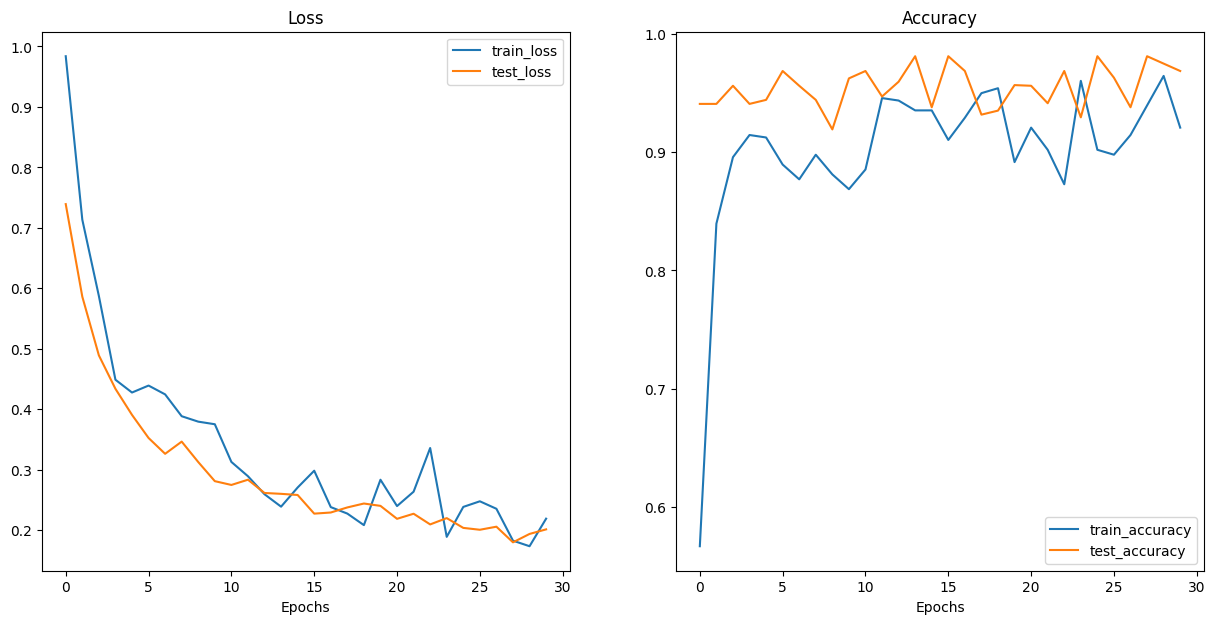

In [15]:
plot_loss_curves(effnetb2_results)

### 3.5 Saving the model

In [16]:
import utils

utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="09_pretrained_effnetb2_feature_extractor.pth")

Saving model to: models/09_pretrained_effnetb2_feature_extractor.pth


### 3.6 Inspecting the size of our model



In [17]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_effnetb2_model_size = Path("models/09_pretrained_effnetb2_feature_extractor.pth").stat().st_size / (1024*1024)
print(f"Pretrained ViT feature extractor model size: {round(pretrained_effnetb2_model_size, 2)} MB")

Pretrained ViT feature extractor model size: 29.84 MB


### 3.7 Colllecting EffNetB2 feature extractor stats

In [18]:
#count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
print(f"Total number of parameters in EffNetB2 is: {effnetb2_total_params}")

Total number of parameters in EffNetB2 is: 7705221


In [19]:
#Crreate a dictionary with EffNetB2 statistics
effnetb2_stats = {"test_loss":effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}

effnetb2_stats

{'test_loss': 0.20136187672615052,
 'test_acc': 0.96875,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29.844857215881348}

## 4. Creating a ViT Feature extractor

### 4.1  Creating a function to make an ViT feature extractor

In [20]:
def create_vit_model(num_classes:int=3, seed:int=42):
    weights= torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    torch.manual_seed(seed)
    model.heads = nn.Sequential(nn.Linear(in_features=768, out_features=num_classes))
    return model, transforms


In [21]:
vit, vit_transforms = create_vit_model(num_classes=3, seed=42)

vit_transforms

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:08<00:00, 39.6MB/s]


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [22]:
summary(model=vit,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20, row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224]     [1, 3]               768                  Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224]     [1, 768, 14, 14]     (590,592)            False
├─Encoder (encoder)                                          [1, 197, 768]        [1, 197, 768]        151,296              False
│    └─Dropout (dropout)                                     [1, 197, 768]        [1, 197, 768]        --                   --
│    └─Sequential (layers)                                   [1, 197, 768]        [1, 197, 768]        --                   False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]        [1, 197, 768]        (7,087,872)          False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]        [1, 1

### 4.2 Create dataloaders for ViT

In [23]:
#setting up dataloaders
train_dataloaders_vit, test_dataloaders_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                     test_dir=test_dir,
                                                                                                     transform=vit_transforms,
                                                                                                     batch_size=32)
train_dataloaders_vit, test_dataloaders_vit, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7d6ae5d75af0>,
 ['pizza', 'steak', 'sushi'])

### 4.3 Training the ViT Feature Extractor

In [24]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=vit.parameters(), lr=0.001)

set_seeds()

vit_results = engine.train(model=vit,
                       train_dataloader=train_dataloaders_vit,
                       test_dataloader=test_dataloaders_vit,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=30,
                       device=device)

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch:1 | train_loss:0.7020, train_acc:0.7521 | test_loss:0.2714, test_acc:0.9381
Epoch:2 | train_loss:0.2532, train_acc:0.9062 | test_loss:0.1672, test_acc:0.9602
Epoch:3 | train_loss:0.1764, train_acc:0.9542 | test_loss:0.1273, test_acc:0.9693
Epoch:4 | train_loss:0.1276, train_acc:0.9625 | test_loss:0.1074, test_acc:0.9722
Epoch:5 | train_loss:0.1159, train_acc:0.9646 | test_loss:0.0953, test_acc:0.9784
Epoch:6 | train_loss:0.1274, train_acc:0.9375 | test_loss:0.0832, test_acc:0.9722
Epoch:7 | train_loss:0.0897, train_acc:0.9771 | test_loss:0.0845, test_acc:0.9784
Epoch:8 | train_loss:0.0919, train_acc:0.9812 | test_loss:0.0764, test_acc:0.9722
Epoch:9 | train_loss:0.0922, train_acc:0.9792 | test_loss:0.0734, test_acc:0.9784
Epoch:10 | train_loss:0.0658, train_acc:0.9833 | test_loss:0.0644, test_acc:0.9847
Epoch:11 | train_loss:0.0592, train_acc:0.9854 | test_loss:0.0606, test_acc:0.9938
Epoch:12 | train_loss:0.0531, train_acc:0.9938 | test_loss:0.0616, test_acc:0.9784
Epoch:13 | tr

### 4.4 Inspecting the loss curves of ViT

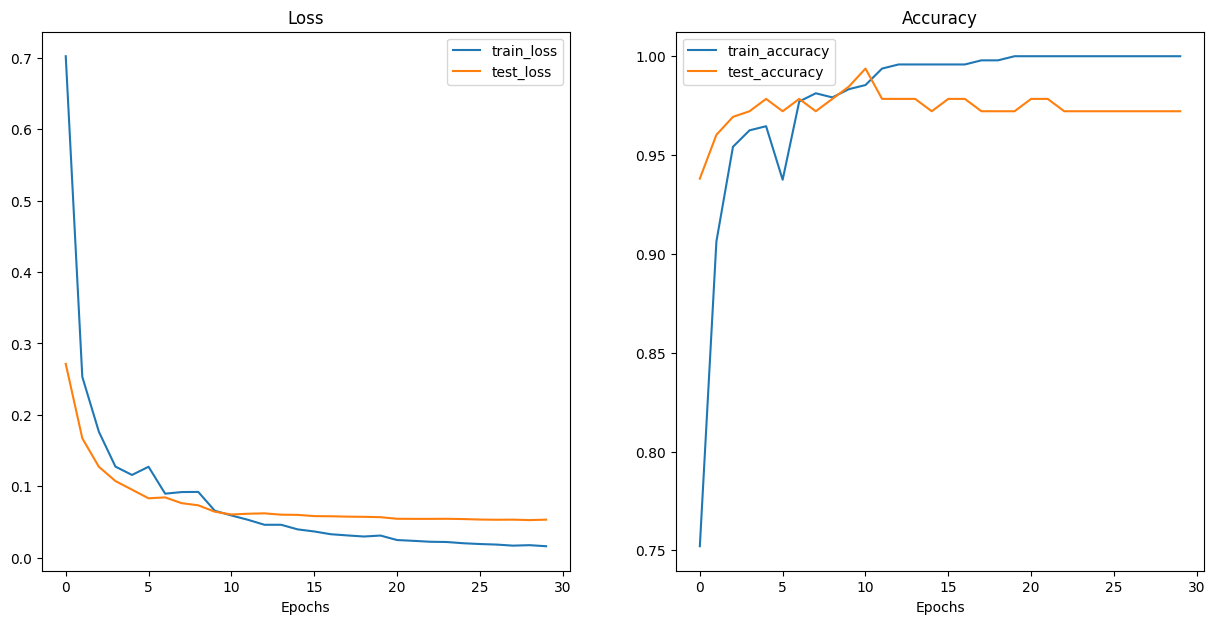

In [25]:
plot_loss_curves(vit_results)

### 4.5 Saving the ViT model

In [26]:
import utils

utils.save_model(model=vit,
                 target_dir="models",
                 model_name="09_pretrained_vit_feature_extractor.pth")

Saving model to: models/09_pretrained_vit_feature_extractor.pth


### 4.6 Inspecting the size of ViT

In [27]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/09_pretrained_vit_feature_extractor.pth").stat().st_size / (1024*1024)
print(f"Pretrained ViT feature extractor model size: {round(pretrained_vit_model_size, 2)} MB")

Pretrained ViT feature extractor model size: 327.37 MB


### 4.7 Collecting ViT Feature extractort stats

In [28]:
#count number of parameters in EffNetB2
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
print(f"Total number of parameters in ViT is: {vit_total_params}")

Total number of parameters in ViT is: 85800963


In [29]:
#Crreate a dictionary with EffNetB2 statistics
vit_stats = {"test_loss":vit_results["test_loss"][-1],
                  "test_acc": vit_results["test_acc"][-1],
                  "number_of_parameters": vit_total_params,
                  "model_size (MB)": pretrained_vit_model_size}

vit_stats

{'test_loss': 0.05333571365335956,
 'test_acc': 0.972159090909091,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327.3669652938843}

## 5. Making predictions with our trained model and timing them

In [30]:
#Get all test data path
test_data_paths = list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/648055.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/1032754.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/788315.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/476421.jpg')]

### 5.1 Creating a function to make predictions across the test dataset

In [31]:
import torch
from typing import List, Dict
import pathlib
from PIL import Image
from timeit import default_timer as timer
from tqdm.auto import tqdm


def pred_and_store(paths:List[pathlib.Path],
                  model:torch.nn.Module,
                  transform:torchvision.transforms,
                  class_names:List[str],
                  device=device) -> List[Dict]:
    pred_list = [] #for returning full list of predictions
    for path in tqdm(paths):
        pred_dict = {}# dictionary to store pred stats and ground truth
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name #ground truth label
        start_time = timer()
        img = Image.open(path) #opening the image here
        transformed_img = transform(img).unsqueeze(0).to(device)
        #preparing the model for inference
        model = model.to(device)
        model.eval()
        with torch.inference_mode():
            pred_logit = model(transformed_img)
            pred_prob = torch.softmax(pred_logit, dim=1)
            pred_label = torch.argmax(pred_prob, dim=1)
            pred_class = class_names[pred_label.cpu()]

            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
            pred_dict["pred_class"] = pred_class

            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time - start_time, 4)

        pred_dict["correct"] = class_name == pred_class

        pred_list.append(pred_dict)

    return pred_list

### 5.2 Making and timing predictions with EffNetB2

In [32]:
effnetb2_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                          model=effnetb2,
                                          transform=effnetb2_transforms,
                                          class_names=class_names,
                                          device="cpu")
effnetb2_test_pred_dicts_gpu = pred_and_store(paths=test_data_paths,
                                          model=effnetb2,
                                          transform=effnetb2_transforms,
                                          class_names=class_names,
                                          device=device)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

In [33]:
effnetb2_test_pred_dicts[:2], effnetb2_test_pred_dicts_gpu[:2]

([{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/648055.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9329,
   'pred_class': 'pizza',
   'time_for_pred': 0.3325,
   'correct': True},
  {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9994,
   'pred_class': 'pizza',
   'time_for_pred': 0.1053,
   'correct': True}],
 [{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/648055.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9329,
   'pred_class': 'pizza',
   'time_for_pred': 0.0914,
   'correct': True},
  {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9994,
   'pred_class': 'pizza',
   'time_for_pred': 0.0319,
   'correct': True}])

In [34]:
#Turn the test_pred_dicts into a dataframe
import pandas as pd
effnetb2_test_pred_df = pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df_gpu = pd.DataFrame(effnetb2_test_pred_dicts_gpu)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/pizza/6...,pizza,0.9329,pizza,0.3325,True
1,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.9994,pizza,0.1053,True
2,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.5298,pizza,0.1052,True
3,data/pizza_steak_sushi_20_percent/test/pizza/7...,pizza,0.8869,pizza,0.1106,True
4,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.9049,pizza,0.1043,True


In [35]:
effnetb2_test_pred_df_gpu.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/pizza/6...,pizza,0.9329,pizza,0.0914,True
1,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.9994,pizza,0.0319,True
2,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.5298,pizza,0.0220,True
3,data/pizza_steak_sushi_20_percent/test/pizza/7...,pizza,0.8869,pizza,0.0214,True
4,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.9049,pizza,0.0214,True


In [36]:
#Check number of correct predictions
effnetb2_test_pred_df.correct.value_counts(), effnetb2_test_pred_df_gpu.correct.value_counts()

(correct
 True     145
 False      5
 Name: count, dtype: int64,
 correct
 True     145
 False      5
 Name: count, dtype: int64)

In [37]:
#Find the average time per prediction
effnetb2_average_time_per_pred = round(effnetb2_test_pred_df.time_for_pred.mean(), 4)
effnetb2_average_time_per_pred_gpu = round(effnetb2_test_pred_df_gpu.time_for_pred.mean(), 4)
print(f"EffNetB2 average time per prediction : {effnetb2_average_time_per_pred}")
print(f"EffNetB2 average time per prediction on GPU : {effnetb2_average_time_per_pred_gpu}")

EffNetB2 average time per prediction : 0.1023
EffNetB2 average time per prediction on GPU : 0.0271


In [38]:
effnetb2_stats["time_per_pred_cpu"] = effnetb2_average_time_per_pred
effnetb2_stats["time_per_pred_gpu"] = effnetb2_average_time_per_pred_gpu

In [39]:
effnetb2_stats

{'test_loss': 0.20136187672615052,
 'test_acc': 0.96875,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29.844857215881348,
 'time_per_pred_cpu': np.float64(0.1023),
 'time_per_pred_gpu': np.float64(0.0271)}

### 5.3 Making and timing predictions with ViT

In [40]:
#Make list of prediction dictionaries with ViT Feature extractor on test images
vit_test_pred_dicts = pred_and_store(paths=test_data_paths,
                                     model=vit,
                                     transform=vit_transforms,
                                     class_names=class_names,
                                     device="cpu")
vit_test_pred_dicts_gpu = pred_and_store(paths=test_data_paths,
                                     model=vit,
                                     transform=vit_transforms,
                                     class_names=class_names,
                                     device=device)

  0%|          | 0/150 [00:00<?, ?it/s]

  0%|          | 0/150 [00:00<?, ?it/s]

In [41]:
vit_test_pred_dicts[:2], vit_test_pred_dicts_gpu[:2]

([{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/648055.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9996,
   'pred_class': 'pizza',
   'time_for_pred': 0.5205,
   'correct': True},
  {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9998,
   'pred_class': 'pizza',
   'time_for_pred': 0.3565,
   'correct': True}],
 [{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/648055.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9996,
   'pred_class': 'pizza',
   'time_for_pred': 0.13,
   'correct': True},
  {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/pizza/1001116.jpg'),
   'class_name': 'pizza',
   'pred_prob': 0.9998,
   'pred_class': 'pizza',
   'time_for_pred': 0.0325,
   'correct': True}])

In [42]:
vit_test_pred_df = pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df_gpu = pd.DataFrame(vit_test_pred_dicts_gpu)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/pizza/6...,pizza,0.9996,pizza,0.5205,True
1,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.9998,pizza,0.3565,True
2,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.9991,pizza,0.3785,True
3,data/pizza_steak_sushi_20_percent/test/pizza/7...,pizza,0.9996,pizza,0.3760,True
4,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.9948,pizza,0.3757,True


In [43]:
vit_test_pred_df_gpu.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/pizza/6...,pizza,0.9996,pizza,0.1300,True
1,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.9998,pizza,0.0325,True
2,data/pizza_steak_sushi_20_percent/test/pizza/1...,pizza,0.9991,pizza,0.0296,True
3,data/pizza_steak_sushi_20_percent/test/pizza/7...,pizza,0.9996,pizza,0.0295,True
4,data/pizza_steak_sushi_20_percent/test/pizza/4...,pizza,0.9948,pizza,0.0298,True


In [44]:
vit_test_pred_df.correct.value_counts(), vit_test_pred_df_gpu.correct.value_counts()

(correct
 True     146
 False      4
 Name: count, dtype: int64,
 correct
 True     146
 False      4
 Name: count, dtype: int64)

In [45]:
vit_average_time_per_pred = round(vit_test_pred_df.time_for_pred.mean(), 4)
vit_average_time_per_pred_gpu = round(vit_test_pred_df_gpu.time_for_pred.mean(), 4)
print(f"ViT average time per prediction : {vit_average_time_per_pred}")
print(f"ViT average time per prediction on GPU : {vit_average_time_per_pred_gpu}")

ViT average time per prediction : 0.399
ViT average time per prediction on GPU : 0.0213


In [46]:
vit_stats["time_per_pred_cpu"] = vit_average_time_per_pred
vit_stats["time_per_pred_gpu"] = vit_average_time_per_pred_gpu

In [47]:
vit_stats

{'test_loss': 0.05333571365335956,
 'test_acc': 0.972159090909091,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327.3669652938843,
 'time_per_pred_cpu': np.float64(0.399),
 'time_per_pred_gpu': np.float64(0.0213)}

## 6. Comparing model results, prediction times and size

In [48]:
#Turn stat dictioanries into DataFrame
df = pd.DataFrame([effnetb2_stats, vit_stats])

df["model"] = ["EffNetB2", "ViT"]

df["test_acc"] = round(df.test_acc * 100, 2)
df

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu,time_per_pred_gpu,model
0,0.201362,96.88,7705221,29.844857,0.1023,0.0271,EffNetB2
1,0.053336,97.22,85800963,327.366965,0.3990,0.0213,ViT


In [49]:
# Comparing ViT to EffNetB2 accross different characteristics
pd.DataFrame(data=(df.set_index("model").loc["ViT"] / df.set_index("model").loc["EffNetB2"]),
             columns=["ViT to EffNetB2 ratios"]).T

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred_cpu,time_per_pred_gpu
ViT to EffNetB2 ratios,0.264875,1.003509,11.135432,10.968957,3.900293,0.785978


### 6.1 Visualizing the speed vs. performance tradeoff

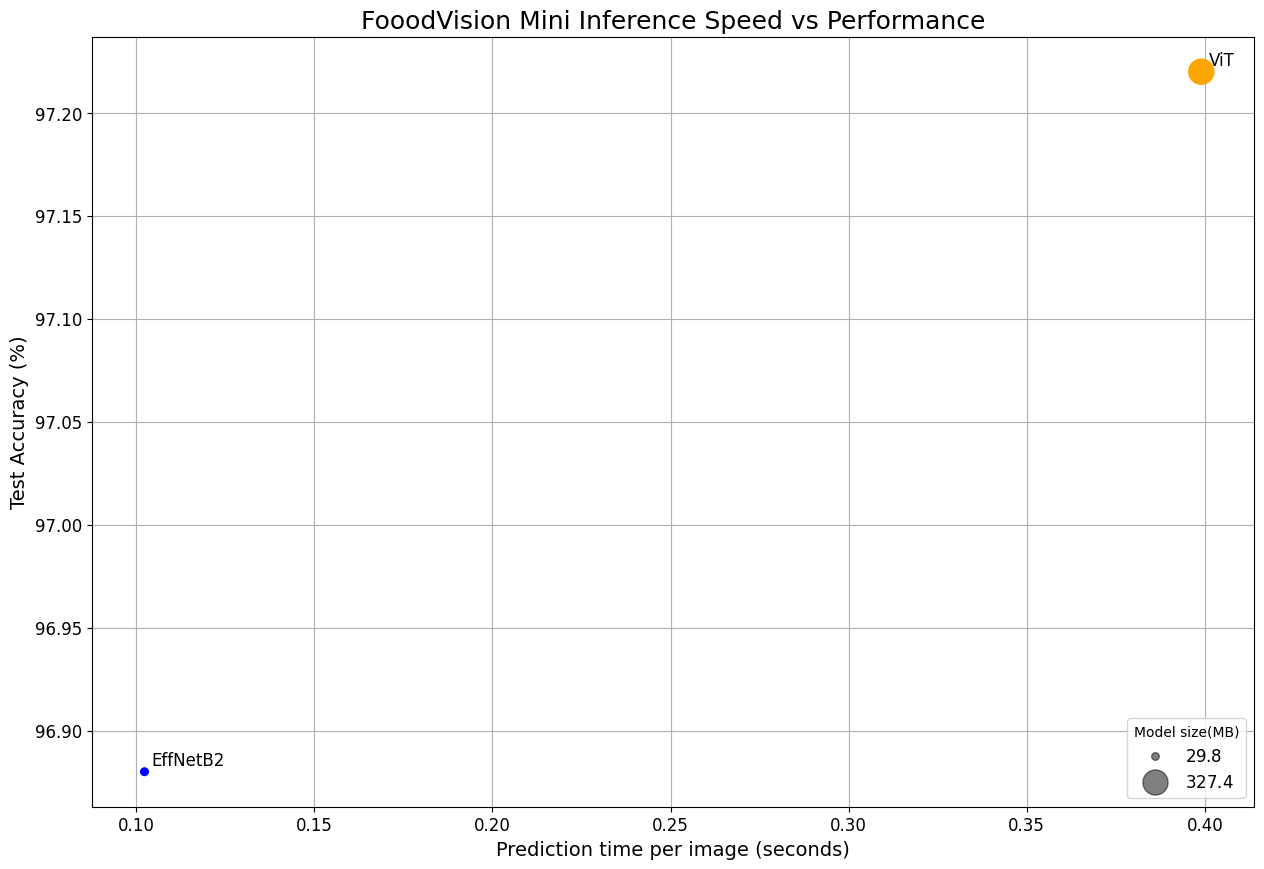

In [50]:
#Creating a plot from model comparison DataFrame
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(15,10))
scatter = ax.scatter(data=df,
                     x="time_per_pred_cpu",
                     y="test_acc",
                     c=["blue", "orange"],
                     s="model_size (MB)")

#Adding titles and labels to our plot
ax.set_title("FooodVision Mini Inference Speed vs Performance", fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test Accuracy (%)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True)

#Annotating the samples on the plot
for index, row in df.iterrows():
  ax.annotate(text=row["model"],
              xy=(row["time_per_pred_cpu"]+0.002, row["test_acc"]+0.003),
              size=12)

  #Creating a legend based on the model sizes
  handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
  model_size_legend = ax.legend(handles, labels, loc="lower right", title="Model size(MB)", fontsize=12)

  #saving the image
  plt.savefig("09-foodvision-mini-inference-speed-vs-performance.png")

## 7. Creating FoodVision Model demo using Gradio

I'm going to use EfficientNet_B2 model to deploying because it's fast and small in size and test accuracy difference is not much also.

In [51]:
try:
  import gradio as gr
except:
  !pip -q install gradio
  import gradio as gr

print(f"Gradio version: {gr.__version__}")

Gradio version: 6.20.0


### 7.1 Creating a function to map our inputs and outputs

In [52]:
#put the model on cpu
effnetb2 = effnetb2.to("cpu")

#check the device
next(iter(effnetb2.parameters())).device

device(type='cpu')

what our functions `predict()` will do
```
image of food -> ML Model (EffNetB2) -> outputs (food class label, prediction time)
```

In [53]:
from typing import Tuple, Dict

def predict(img) -> Tuple[Dict, float]:
  #Start a timer
  start_time = timer()

  #Transform the input image for use with EffNetB2
  img = effnetb2_transforms(img).unsqueeze(0)

  #Put the model into eval mode to make prediction
  effnetb2.eval()
  with torch.inference_mode():
    pred_probs = torch.softmax(effnetb2(img), dim=1)

  #Create a prediction label and predcition
  pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}

  #Calculate pred time
  pred_time = round(timer() - start_time, 5)

  #Return pred dict and pred time
  return pred_labels_and_probs, pred_time

In [54]:
import random
from PIL import Image

test_data_paths = list(Path(test_dir).glob("*/*.jpg"))

random_image_path = random.sample(test_data_paths, k=1)[0]
random_image_path
image = Image.open(random_image_path)
print(f"[INFO] Predicting on image at path: {random_image_path}")

pred_dict, pred_time = predict(img=image)
pred_dict, pred_time

[INFO] Predicting on image at path: data/pizza_steak_sushi_20_percent/test/pizza/833711.jpg


({'pizza': 0.9152467250823975,
  'steak': 0.06858375668525696,
  'sushi': 0.016169529408216476},
 0.08494)

### 7.2 Creating a list of examples images

In [55]:
example_list = [[str(filepath)] for filepath in random.sample(test_data_paths, k=3)]
example_list

[['data/pizza_steak_sushi_20_percent/test/pizza/796922.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/steak/48208.jpg'],
 ['data/pizza_steak_sushi_20_percent/test/pizza/3729167.jpg']]

### 7.3 Building a Gradio Interface

In [56]:
from gradio import Interface
#Create title, description and article
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images as pizza, steak or sushi."
article = "Created on pytorch model deployment"

#Creating gradio demo
demo = gr.Interface(fn=predict,
                    inputs=gr.Image(type="pil"),
                    outputs=[gr.Label(num_top_classes=3, label="predictions"),
                             gr.Number(label="Prediction time(s)")],
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)

#Launch the demo!
demo.launch(debug=False,
             share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://45ec863a03f498cf14.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 8. Turning our FoodVision Mini Gradio Demo into a deployable app


### 8.1 Deployed Gradio app structure
To upload our demo Gradio app, we'll want to put everything relating to it into a single directory.

For example, our demo might live at the path demos/foodvision_mini/ with the file structure:


$demos/$

  └──$ foodvisionmini/$

      ├── 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
      ├── app.py
      ├── examples/
      │   ├── example_1.jpg
      │   ├── example_2.jpg
      │   └── example_3.jpg
      ├── model.py
      └── requirements.txt

Where:

  * 09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth is our trained PyTorch model file.
  * app.py contains our Gradio app (similar to the code that launched the app).
  * Note: app.py is the default filename used for Hugging Face Spaces, if you deploy your app there, Spaces will by default look for a file called app.py to run. This is changeable in settings.
  * examples/ contains example images to use with our Gradio app.
  * model.py contains the model definition as well as any transforms associated with the model.
  * requirements.txt contains the dependencies to run our app such as torch, torchvision and gradio.

### 8.2 Creating a demos folder to store our FoodVision Mini app files

In [57]:
import shutil
from pathlib import Path

#Creating foodvision mini demo path
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

#Removes files that might exists and create a new directory
if foodvision_mini_demo_path.exists():
  shutil.rmtree(foodvision_mini_demo_path)
  foodvision_mini_demo_path.mkdir(parents=True, exist_ok=True)
else:
  foodvision_mini_demo_path.mkdir(parents=True, exist_ok=True)

!ls demos/foodvision_mini/


### 8.3 Creating a folder of examples images to use with our FoodVision Mini demo

In [58]:
foodvision_mini_examples_path = foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(parents=True, exist_ok=True)

#Collect three random test dataset image paths
foodvision_mini_examples = [Path('data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg')]

#Copy the three random images to the examples directory
for example in foodvision_mini_examples:
    destination = foodvision_mini_examples_path / example.name
    print(f"[INFO] Copying {example} to {destination}")
    shutil.copy2(src=example, dst=destination)

[INFO] Copying data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg to demos/foodvision_mini/examples/592799.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg to demos/foodvision_mini/examples/3622237.jpg
[INFO] Copying data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg to demos/foodvision_mini/examples/2582289.jpg


In [59]:
import os

#Get the examples path as list of list as gradio only works with these
example_list = [["examples/" + example] for example in os.listdir(foodvision_mini_examples_path)]
example_list

[['examples/592799.jpg'], ['examples/3622237.jpg'], ['examples/2582289.jpg']]

### 8.4 Moving our trained EffNetB2 model to our FoodVision Mini demo directory

In [60]:
effnetb2_foodvision_mini_model_path = Path("/content/models/09_pretrained_effnetb2_feature_extractor.pth")
#Create a destination path for the target model
effnetb2_foodvision_mini_model_destination = foodvision_mini_demo_path / effnetb2_foodvision_mini_model_path.name

try:
  print(f"[INFO] Attempting to move {effnetb2_foodvision_mini_model_path} to {effnetb2_foodvision_mini_model_destination}")
  shutil.move(src=effnetb2_foodvision_mini_model_path,
              dst=effnetb2_foodvision_mini_model_destination)
  print(f"[INFO] Successfully moved the model")
except:
  print(f"[INFO] No model found at {effnetb2_foodvision_mini_model_path}, perhaps it has already been moved?")
  print(f"[INFO] model exists at {effnetb2_foodvision_mini_model_destination}: {effnetb2_foodvision_mini_model_destination.exists()}")

[INFO] Attempting to move /content/models/09_pretrained_effnetb2_feature_extractor.pth to demos/foodvision_mini/09_pretrained_effnetb2_feature_extractor.pth
[INFO] Successfully moved the model


### 8.5 Turning off EffNetB2 model into a Python script (`model.py`)

In [68]:
%%writefile demos/foodvision_mini/model_effnetb2.py

import torch
import torch.nn as nn
import torchvision

def create_effnetb2_model(num_classes:int=3, seed:int=42):
    """This Function creates EfficientNetB2 model instance """
    weights= torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes)
    )
    return model, transforms


Writing demos/foodvision_mini/model_effnetb2.py


### 8.6 Turning our FoodVision Mini Gradio app into a Python script (`app.py`)

In [62]:
%%writefile demos/foodvision_mini/app.py
import gradio as gr
import os
import torch

from model import create_effnetb2_model
from timeit import default_timer as timer
from typing import Tuple, Dict

# Setup class names
class_names = ["pizza", "steak", "sushi"]

# Create EffNetB2 model
effnetb2, effnetb2_transforms = create_effnetb2_model(
    num_classes=3, # len(class_names) would also work
)

# Load saved weights
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth",
        map_location=torch.device("cpu"),  # load to CPU
    )
)

# Create predict function
def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()

    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)

    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)

    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}

    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)

    # Return the prediction dictionary and prediction time
    return pred_labels_and_probs, pred_time

# Create title, description and article strings
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"), # what are the inputs?
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # what are the outputs?
                             gr.Number(label="Prediction time (s)")], # our fn has two outputs, therefore we have two outputs
                    # Create examples list from "examples/" directory
                    examples=example_list,
                    title=title,
                    description=description,
                    article=article)

# Launch the demo!
demo.launch()

Writing demos/foodvision_mini/app.py


### 8.7 Creating a requirements file for FoodVision mini (`requirements.txt`)

In [63]:
%%writefile demos/foodvision_mini/requirements.text

torch==2.10.0
torchvision=0.25.0
gradio==6.20.0

Writing demos/foodvision_mini/requirements.text
